<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Projet 12 - Modélisations</h1>

In [38]:
#____ Imports généraux ____#
import os
import warnings
import joblib
import json
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#____ Sklearn — prétraitement et pipeline ____#
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import (
    KFold,
    TimeSeriesSplit,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate,
    cross_val_score,
    learning_curve,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.inspection import permutation_importance

#____ Sklearn — modèles ____#
from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
)

#____ Modèles boosting avancés ____#
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

#____ MLflow ____#
import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")

#____ Reproductibilité ____#
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#____ Suppression des warnings Python ____#
warnings.filterwarnings("ignore")

#____ Suppression des warnings MLflow ____#
logging.getLogger("mlflow").setLevel(logging.ERROR)

print("Imports effectués avec succès.")

Imports effectués avec succès.


In [2]:
# Configuration MLflow

MLFLOW_EXPERIMENT_NAME = "agritech-yield-prediction"

mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print(f"Expérience MLflow configurée : '{MLFLOW_EXPERIMENT_NAME}'")
print(f"URI de tracking : mlruns/")

Expérience MLflow configurée : 'agritech-yield-prediction'
URI de tracking : mlruns/


<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Préparation du dataset</h1>

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Audit - check</h2>

In [3]:
# Chargement du dataset principal

DATASET_PATH = os.path.join("..", "outputs", "dataset_final.csv")

df = pd.read_csv(DATASET_PATH)

print(f"Dimensions : {df.shape}")
print(f"Colonnes   : {list(df.columns)}")
df.head()

Dimensions : (13130, 7)
Colonnes   : ['Area', 'Item', 'Year', 'hg_ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,Area,Item,Year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


In [4]:
# Types de données
# Valeurs manquantes
# Doublons

print("=== Types de données ===")
print(df.dtypes)
print()

print("=== Valeurs manquantes ===")
print(df.isnull().sum())
print()

print("=== Doublons ===")
print(f"Nombre de doublons : {df.duplicated().sum()}")

=== Types de données ===
Area                              object
Item                              object
Year                               int64
hg_ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

=== Valeurs manquantes ===
Area                             0
Item                             0
Year                             0
hg_ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

=== Doublons ===
Nombre de doublons : 0


In [5]:
# Statistiques descriptives
df.describe()

,Year,hg_ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,13130.000000,13130.000000,13130.000000,13130.000000,13130.000000
mean,2001.622772,70968.615461,1157.238766,14838.697886,19.836531
std,7.033139,79124.283809,743.622488,33652.454670,6.658083
min,1990.000000,50.000000,51.000000,0.040000,1.300000
25%,1995.000000,18000.000000,608.000000,264.530000,15.670000
50%,2001.000000,39543.500000,1083.000000,2172.200000,20.620000
75%,2008.000000,97152.250000,1651.000000,13335.220000,25.780000
max,2013.000000,501412.000000,3240.000000,367778.000000,30.420000


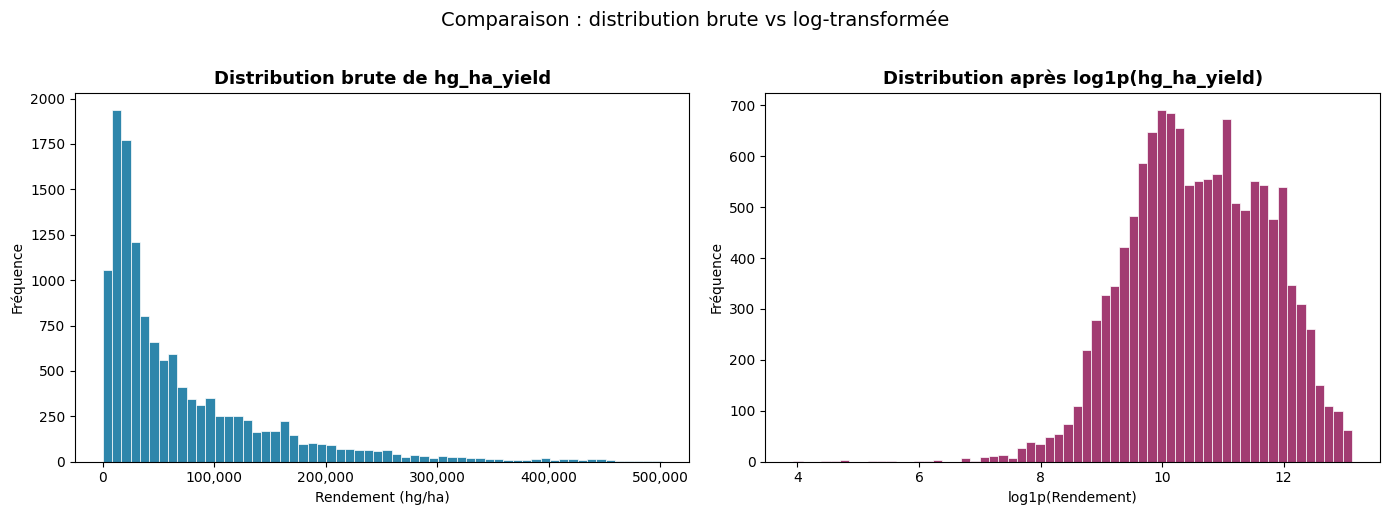

Skewness brut  : 2.0768
Skewness log1p : -0.2225


In [6]:
# Comparaison : distribution brute vs log-transformée

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df["hg_ha_yield"], bins=60, color="#2E86AB", edgecolor="white", linewidth=0.5)
axes[0].set_title("Distribution brute de hg_ha_yield", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Rendement (hg/ha)")
axes[0].set_ylabel("Fréquence")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Distribution après transformation log1p
axes[1].hist(np.log1p(df["hg_ha_yield"]), bins=60, color="#A23B72", edgecolor="white", linewidth=0.5)
axes[1].set_title("Distribution après log1p(hg_ha_yield)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("log1p(Rendement)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Comparaison : distribution brute vs log-transformée", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/distrib_target.png", dpi=150, bbox_inches="tight")
plt.show()

skew_brut = df["hg_ha_yield"].skew()
skew_log  = np.log1p(df["hg_ha_yield"]).skew()
print(f"Skewness brut  : {skew_brut:.4f}")
print(f"Skewness log1p : {skew_log:.4f}")

=== Répartition des observations par culture ===
  Potatoes                    2091 observations  (15.93%)
  Maize                       2028 observations  (15.45%)
  Wheat                       1810 observations  (13.79%)
  Rice, paddy                 1502 observations  (11.44%)
  Sorghum                     1435 observations  (10.93%)
  Soybeans                    1242 observations  (9.46%)
  Sweet potatoes              1163 observations  (8.86%)
  Cassava                      941 observations  (7.17%)
  Plantains and others         464 observations  (3.53%)
  Yams                         454 observations  (3.46%)


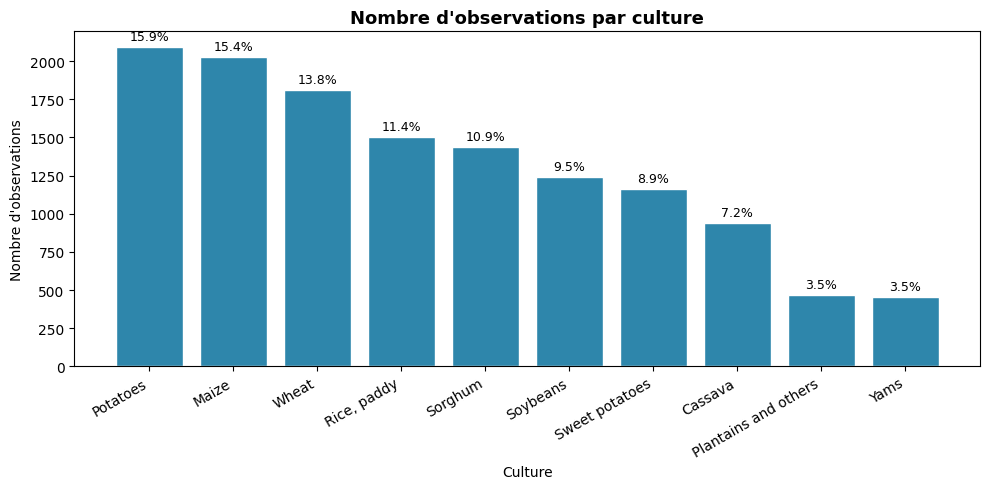

'\n\n---\n\n**Cellule 2.7 — Markdown**\n'

In [7]:
# Observartion par cultures

item_counts = df["Item"].value_counts()
item_pct    = (item_counts / len(df) * 100).round(2)

print("=== Répartition des observations par culture ===")
for culture, n, pct in zip(item_counts.index, item_counts.values, item_pct.values):
    print(f"  {culture:<25} {n:>6} observations  ({pct:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(item_counts.index, item_counts.values, color="#2E86AB", edgecolor="white")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in item_pct.values], padding=3, fontsize=9)
ax.set_title("Nombre d'observations par culture", fontsize=13, fontweight="bold")
ax.set_xlabel("Culture")
ax.set_ylabel("Nombre d'observations")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../outputs/distrib_item.png", dpi=150, bbox_inches="tight")
plt.show()
'''

---

**Cellule 2.7 — Markdown**
'''
### 2.3 — Distribution par pays (`Area`)

Nombre total de pays : 101

=== Top 10 pays les plus représentés ===
Area
Kenya       230
Cameroon    230
Uganda      207
Burundi     207
Rwanda      207
Peru        207
Ecuador     207
Mali        207
Colombia    207
Brazil      207

=== Top 10 pays les moins représentés ===
Area
Finland       46
Ireland       46
Norway        46
Sweden        46
Latvia        42
Estonia       42
Belgium       39
Bahrain       29
Montenegro    24
Sudan         14

Pays avec moins de 10 observations : 0
Pays avec moins de 5 observations  : 0


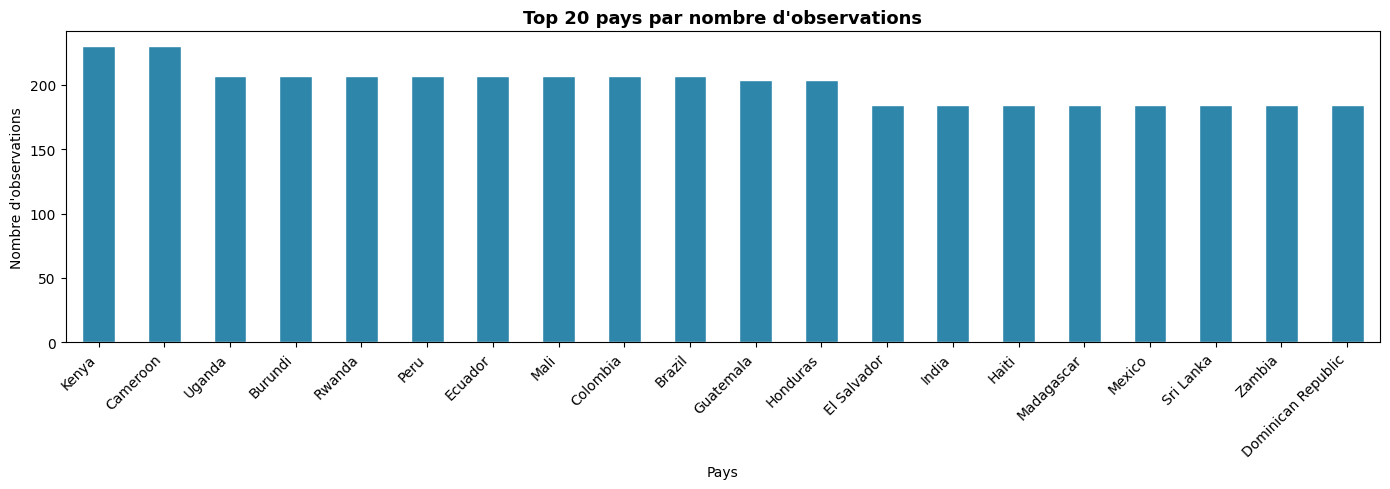

In [8]:
# Distribution par pays (Area)

area_counts = df["Area"].value_counts()

print(f"Nombre total de pays : {df['Area'].nunique()}")
print()
print("=== Top 10 pays les plus représentés ===")
print(area_counts.head(10).to_string())
print()
print("=== Top 10 pays les moins représentés ===")
print(area_counts.tail(10).to_string())
print()
print(f"Pays avec moins de 10 observations : {(area_counts < 10).sum()}")
print(f"Pays avec moins de 5 observations  : {(area_counts < 5).sum()}")

fig, ax = plt.subplots(figsize=(14, 5))
area_counts.head(20).plot(kind="bar", ax=ax, color="#2E86AB", edgecolor="white")
ax.set_title("Top 20 pays par nombre d'observations", fontsize=13, fontweight="bold")
ax.set_xlabel("Pays")
ax.set_ylabel("Nombre d'observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/distrib_area.png", dpi=150, bbox_inches="tight")
plt.show()

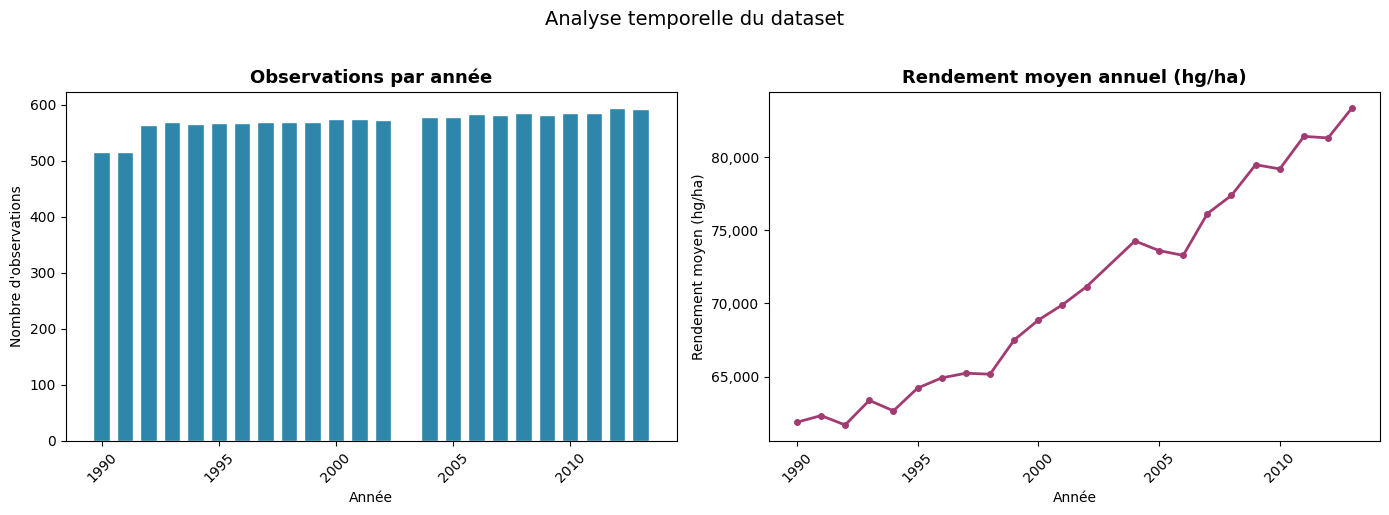

Années disponibles : [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013)]
Années manquantes  : [2003]


In [9]:
# Distribution temporelle (Year)

year_counts      = df["Year"].value_counts().sort_index()
rendement_annuel = df.groupby("Year")["hg_ha_yield"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nombre d'observations par année
axes[0].bar(year_counts.index, year_counts.values, color="#2E86AB", edgecolor="white", width=0.7)
axes[0].set_title("Observations par année", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre d'observations")
axes[0].tick_params(axis="x", rotation=45)

# Tendance du rendement moyen
axes[1].plot(
    rendement_annuel.index, rendement_annuel.values,
    marker="o", color="#A23B72", linewidth=2, markersize=4
)
axes[1].set_title("Rendement moyen annuel (hg/ha)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Rendement moyen (hg/ha)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Analyse temporelle du dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/distrib_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Années disponibles : {sorted(df['Year'].unique())}")
print(f"Années manquantes  : {[y for y in range(df['Year'].min(), df['Year'].max()+1) if y not in df['Year'].unique()]}")

### 3.1 — Définition des features et de la cible

### <u>Conclusion de l'audit — dataset_final.csv</u>

#### Structure générale

On a 7 colonnes, aucune valeur manquante, aucun doublon.
Les types sont cohérents : `Area` et `Item` en object (variables catégorielles),
`Year` en int64, les variables numériques en float64.

#### Variable cible `hg_ha_yield`

- Skewness brut : 2.0768 — asymétrie droite prononcée.
- Skewness après log1p : -0.2225 — distribution quasi-symétrique obtenue.
- <mark>Décision retenue</mark> : transformation `log1p` appliquée sur la cible pour l'entraînement.
  Les prédictions seront ramenées à l'échelle originale via `expm1()`.
- Plage de valeurs : 50 à 501 412 hg/ha. La médiane (39 543 hg/ha) est très inférieure
  à la moyenne (70 968 hg/ha), ce qui confirme l'effet de la longue queue droite.

#### Distribution par culture (`Item`)

**10 cultures présentes**. La distribution est relativement équilibrée sur les 8 premières
cultures (entre 7.2% et 15.9%). Les deux dernières sont nettement sous-représentées :
- Plantains and others : 464 observations (3.53%)
- Yams : 454 observations (3.46%)

#### Distribution par pays (`Area`)

**101 pays présents**. La répartition est globalement homogène — le top 20 se situe
entre 183 et 230 observations par pays, sans écart majeur.
Aucun pays n'a moins de 10 observations : le risque d'instabilité lors de l'encodage
est nul. La structure est solide pour l'OrdinalEncoder.

#### Distribution temporelle (`Year`)

- **Couverture : 1990-2013**, avec une seule année manquante (2003).
- Nombre d'observations stable par année (~510 à 590).
- Tendance haussière claire du rendement moyen : de ~62 000 hg/ha en 1990
  à ~88 000 hg/ha en 2013 — progression de +42% sur la période.
- Cette tendance justifie le <mark>split temporel (seuil 2010) plutôt qu'un split aléatoire</mark>.

#### <u>Décisions confirmées pour la modélisation</u>

| Décision | Justification |
|---|---|
| Transformation `log1p` sur `hg_ha_yield` | Skewness 2.07 -> -0.22 |
| `OrdinalEncoder` pour `Area` et `Item` | 101 pays, pas d'instabilité, arbres incompatibles avec OHE massif |
| Split temporel seuil 2010 | Tendance haussière +42%, risque de data leakage temporel |
| Modèles ensemblistes privilégiés | Relations non linéaires confirmées à l'étape 1 |
| Surveillance RMSE sur Plantains et Yams | Sous-représentation 3.5% chacun |

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Préparation des données</h2>

In [10]:
# Définition des features et de la cible
FEATURES_CAT = ["Area", "Item"]
FEATURES_NUM = ["Year", "average_rain_fall_mm_per_year", "pesticides_tonnes", "avg_temp"]
FEATURES_ALL = FEATURES_CAT + FEATURES_NUM
TARGET       = "hg_ha_yield"

# Application de la transformation log1p sur la cible
X = df[FEATURES_ALL].copy()
y = np.log1p(df[TARGET])

print(f"Features catégorielles : {FEATURES_CAT}")
print(f"Features numériques    : {FEATURES_NUM}")
print(f"Cible (log1p)          : {TARGET}")
print(f"Shape X : {X.shape}")
print(f"Shape y : {y.shape}")
### 3.2 — 

Features catégorielles : ['Area', 'Item']
Features numériques    : ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Cible (log1p)          : hg_ha_yield
Shape X : (13130, 6)
Shape y : (13130,)


In [11]:
# Split temporel train / test
# Split temporel : années <= 2010 pour l'entraînement, > 2010 pour le test.
# Justification : éviter la fuite de données temporelle (data leakage).
# Le modèle est évalué sur des années qu'il n'a jamais vues.
SEUIL_TEMPOREL = 2010

mask_train = df["Year"] <= SEUIL_TEMPOREL
mask_test  = df["Year"] >  SEUIL_TEMPOREL

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]

print(f"Seuil temporel : années <= {SEUIL_TEMPOREL} -> train | > {SEUIL_TEMPOREL} -> test")
print(f"Taille train   : {X_train.shape[0]} observations ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Taille test    : {X_test.shape[0]} observations ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Années train   : {sorted(X_train['Year'].unique())}")
print(f"Années test    : {sorted(X_test['Year'].unique())}")

Seuil temporel : années <= 2010 -> train | > 2010 -> test
Taille train   : 11360 observations (86.5%)
Taille test    : 1770 observations (13.5%)
Années train   : [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]
Années test    : [np.int64(2011), np.int64(2012), np.int64(2013)]


In [12]:
# Vérification de cohérence : toutes les modalités du test sont-elles dans le train ?
for col in FEATURES_CAT:
    modalites_train = set(X_train[col].unique())
    modalites_test  = set(X_test[col].unique())
    inconnues       = modalites_test - modalites_train
    if inconnues:
        print(f"[ATTENTION] {col} : {len(inconnues)} modalité(s) dans le test absente(s) du train")
        print(f"  -> {inconnues}")
    else:
        print(f"[OK] {col} : toutes les modalités du test sont présentes dans le train.")

[ATTENTION] Area : 1 modalité(s) dans le test absente(s) du train
  -> {'Sudan'}
[OK] Item : toutes les modalités du test sont présentes dans le train.


In [13]:
# Suppression de Sudan : 14 observations toutes postérieures à 2010,
# donc intégralement dans le jeu de test — modalité jamais vue à l'entraînement.
df = df[df["Area"] != "Sudan"].reset_index(drop=True)

# Reconstruction de X, y et des splits après suppression
X = df[FEATURES_ALL].copy()
y = np.log1p(df[TARGET])

mask_train = df["Year"] <= SEUIL_TEMPOREL
mask_test  = df["Year"] >  SEUIL_TEMPOREL

X_train = X[mask_train]
X_test  = X[mask_test]
y_train = y[mask_train]
y_test  = y[mask_test]

print(f"Sudan supprimé.")
print(f"Nouvelles dimensions : {df.shape}")
print(f"Taille train : {X_train.shape[0]} | Taille test : {X_test.shape[0]}")

# Vérification finale
for col in FEATURES_CAT:
    inconnues = set(X_test[col].unique()) - set(X_train[col].unique())
    if inconnues:
        print(f"[ATTENTION] {col} : modalités inconnues -> {inconnues}")
    else:
        print(f"[OK] {col} : toutes les modalités du test sont présentes dans le train.")

Sudan supprimé.
Nouvelles dimensions : (13116, 7)
Taille train : 11360 | Taille test : 1756
[OK] Area : toutes les modalités du test sont présentes dans le train.
[OK] Item : toutes les modalités du test sont présentes dans le train.


<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Construction du pipeline</h2>

In [14]:
# Prétraitement encapsulé dans un ColumnTransformer.

# Colonnes numériques  : StandardScaler
# Normalisation utile pour Ridge, neutre pour les arbres.

# Colonnes catégorielles : OrdinalEncoder
#   Justification du choix OrdinalEncoder vs OneHotEncoder :
#   101 pays + 10 cultures en OHE produiraient 110+ colonnes binaires,
#   contre-productif pour les modèles à base d'arbres.
#   L'OrdinalEncoder encode chaque modalité en entier, compatible avec tous les modèles.
#   handle_unknown="use_encoded_value" avec unknown_value=-1 sécurise les inconnues éventuelles.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), FEATURES_CAT),
    ],
    remainder="drop"
)

print("Pipeline de prétraitement défini.")
print(f"  Numériques    : {FEATURES_NUM} -> StandardScaler")
print(f"  Catégorielles : {FEATURES_CAT} -> OrdinalEncoder")

Pipeline de prétraitement défini.
  Numériques    : ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'] -> StandardScaler
  Catégorielles : ['Area', 'Item'] -> OrdinalEncoder


<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Modélisation</h1>

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Test et sélection des modèles candidats</h2>

In [15]:
# Définition des 7 modèles
# Les 7 modèles sont instanciés avec uniquement random_state=42.
# Aucun hyperparamètre personnalisé à ce stade : comparaison avec default parameters.
#
# Modèle 1 — Ridge              : baseline linéaire, quantifie le gain des modèles non linéaires
# Modèle 2 — RandomForest       : référence de la littérature, robuste aux outliers
# Modèle 3 — GradientBoosting   : implémentation sklearn classique
# Modèle 4 — ExtraTrees         : variante RF avec randomisation plus poussée
# Modèle 5 — XGBoost            : standard industrie données tabulaires
# Modèle 6 — LightGBM           : plus rapide que XGBoost, efficace sur taille intermédiaire
# Modèle 7 — CatBoost           : meilleur sur données avec variables catégorielles
RANDOM_STATE = 42
modeles = {
    "Ridge"           : Ridge(),
    "RandomForest"    : RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "ExtraTrees"      : ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost"         : XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM"        : LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    "CatBoost"        : CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}

print(f"{len(modeles)} modèles définis :")
for nom in modeles:
    print(f"  - {nom}")

7 modèles définis :
  - Ridge
  - RandomForest
  - GradientBoosting
  - ExtraTrees
  - XGBoost
  - LightGBM
  - CatBoost


In [16]:
# Fonction d'évaluation cross-validée

def evaluer_modele_cv(nom, modele, preprocessor, X_train, y_train, cv_strategy):
    """
    Construit un pipeline sklearn (preprocesseur + modèle) et l'évalue par cross-validation.
    Retourne un dictionnaire contenant la moyenne et l'écart-type des métriques RMSE, R², MAE.
    Les métriques sont calculées sur les valeurs log-transformées (cohérence avec la cible).
    """
    pipeline = Pipeline([
        ("preprocesseur", preprocessor),
        ("modele", modele)
    ])

    scoring = {
        "rmse" : "neg_root_mean_squared_error",
        "r2"   : "r2",
        "mae"  : "neg_mean_absolute_error",
    }

    resultats_cv = cross_validate(
        pipeline, X_train, y_train,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    metrics = {
        "cv_rmse_mean" : -resultats_cv["test_rmse"].mean(),
        "cv_rmse_std"  :  resultats_cv["test_rmse"].std(),
        "cv_r2_mean"   :  resultats_cv["test_r2"].mean(),
        "cv_r2_std"    :  resultats_cv["test_r2"].std(),
        "cv_mae_mean"  : -resultats_cv["test_mae"].mean(),
        "cv_mae_std"   :  resultats_cv["test_mae"].std(),
    }

    return metrics


print("Fonction d'évaluation définie.")

Fonction d'évaluation définie.


In [17]:
# Entraînement et logging MLflow (KFold 5, paramètres par défaut)
# Stratégie principale : KFold avec shuffle.
# Avec 13 130 observations et 10 cultures bien réparties, le shuffle garantit
    # une distribution homogène de la cible dans chaque fold.
# C'est l'équivalent pratique d'une stratification en régression.

cv_kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultats_baseline = {}

print("Lancement de la phase de comparaison baseline (KFold 5)...")
print("-" * 65)

for nom, modele in modeles.items():
    with mlflow.start_run(run_name=f"{nom}_baseline"):

        # Tags de contexte
        mlflow.set_tag("phase", "comparaison_baseline")
        mlflow.set_tag("cv_strategy", "KFold_5_shuffle")
        mlflow.set_tag("split", f"temporel_seuil_{SEUIL_TEMPOREL}")

        # Paramètres
        mlflow.log_param("modele", nom)
        mlflow.log_param("n_splits", 5)
        mlflow.log_param("shuffle", True)
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("target_transform", "log1p")

        # Evaluation cross-validée
        metrics = evaluer_modele_cv(nom, modele, preprocessor, X_train, y_train, cv_kfold)

        # Log des métriques
        mlflow.log_metrics(metrics)

        resultats_baseline[nom] = metrics

        print(
            f"  {nom:<22} | RMSE={metrics['cv_rmse_mean']:.4f} "
            f"(+/-{metrics['cv_rmse_std']:.4f}) "
            f"| R²={metrics['cv_r2_mean']:.4f} "
            f"(+/-{metrics['cv_r2_std']:.4f})"
        )

print("-" * 65)
print("Phase baseline terminée. Runs loggées dans MLflow.")

Lancement de la phase de comparaison baseline (KFold 5)...
-----------------------------------------------------------------
  Ridge                  | RMSE=1.0766 (+/-0.0060) | R²=0.0834 (+/-0.0062)
  RandomForest           | RMSE=0.2458 (+/-0.0261) | R²=0.9517 (+/-0.0111)
  GradientBoosting       | RMSE=0.5042 (+/-0.0110) | R²=0.7988 (+/-0.0098)
  ExtraTrees             | RMSE=0.2129 (+/-0.0071) | R²=0.9641 (+/-0.0027)
  XGBoost                | RMSE=0.2706 (+/-0.0193) | R²=0.9418 (+/-0.0088)
  LightGBM               | RMSE=0.3264 (+/-0.0143) | R²=0.9156 (+/-0.0077)
  CatBoost               | RMSE=0.2907 (+/-0.0115) | R²=0.9330 (+/-0.0055)
-----------------------------------------------------------------
Phase baseline terminée. Runs loggées dans MLflow.


In [18]:
# Tableau comparatif et visualisation
# Tableau de synthèse trié par RMSE croissant (meilleur modèle en premier)
df_resultats = pd.DataFrame(resultats_baseline).T
df_resultats = df_resultats.sort_values("cv_rmse_mean")
df_resultats.index.name = "Modèle"

print("=== Classement des modèles (KFold 5, paramètres par défaut) ===")
print(
    df_resultats[[
        "cv_rmse_mean", "cv_rmse_std",
        "cv_r2_mean",   "cv_r2_std",
        "cv_mae_mean"
    ]].to_string()
)

=== Classement des modèles (KFold 5, paramètres par défaut) ===
                  cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std  cv_mae_mean
Modèle                                                                         
ExtraTrees            0.212879     0.007150    0.964103   0.002678     0.121561
RandomForest          0.245805     0.026107    0.951656   0.011090     0.139469
XGBoost               0.270557     0.019259    0.941790   0.008758     0.181626
CatBoost              0.290727     0.011525    0.933040   0.005507     0.206590
LightGBM              0.326425     0.014251    0.915559   0.007677     0.235536
GradientBoosting      0.504230     0.011022    0.798798   0.009758     0.372225
Ridge                 1.076582     0.006041    0.083408   0.006196     0.884097


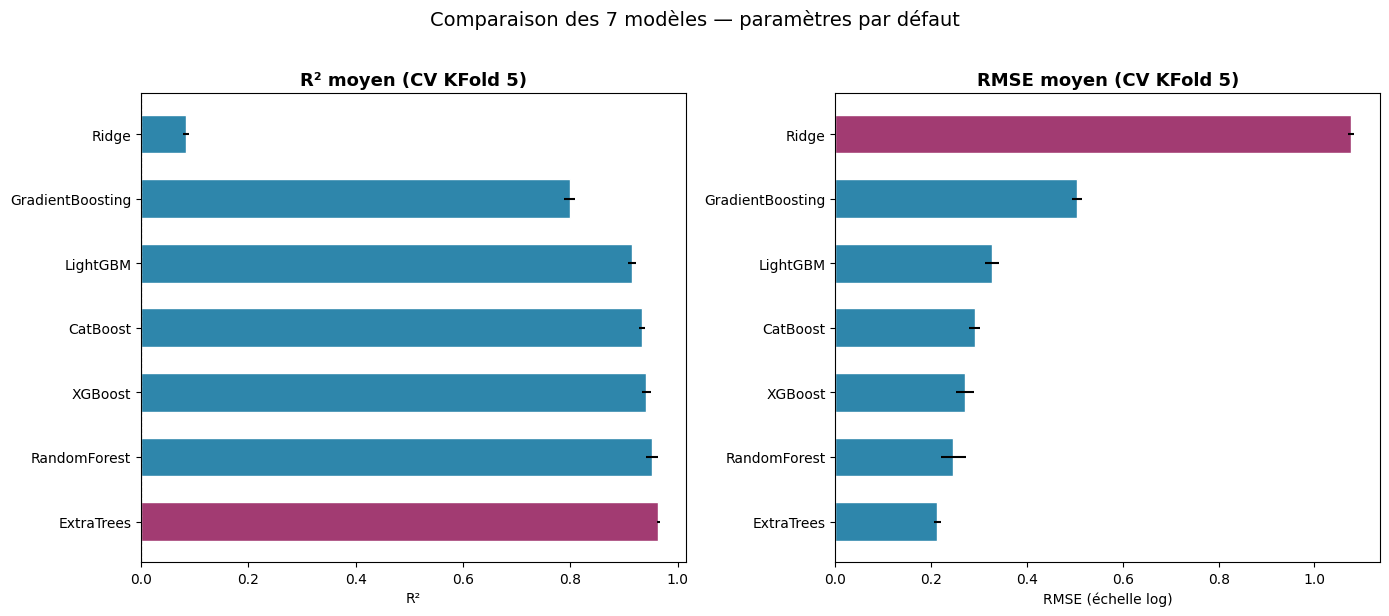

Visualisation sauvegardée : ../outputs/comparaison_baseline.png


In [19]:
modeles_ordonnes = df_resultats.index.tolist()

# Le meilleur modèle (index 0) est mis en valeur avec une couleur distincte
couleurs_r2   = ["#A23B72" if i == 0 else "#2E86AB" for i in range(len(modeles_ordonnes))]
couleurs_rmse = list(reversed(couleurs_r2))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# R² moyen avec barres d'erreur
axes[0].barh(
    modeles_ordonnes,
    df_resultats["cv_r2_mean"],
    xerr=df_resultats["cv_r2_std"],
    color=couleurs_r2, edgecolor="white", height=0.6
)
axes[0].set_title("R² moyen (CV KFold 5)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("R²")
axes[0].axvline(x=0, color="black", linewidth=0.8, linestyle="--")

# RMSE moyen avec barres d'erreur
axes[1].barh(
    modeles_ordonnes,
    df_resultats["cv_rmse_mean"],
    xerr=df_resultats["cv_rmse_std"],
    color=couleurs_rmse, edgecolor="white", height=0.6
)
axes[1].set_title("RMSE moyen (CV KFold 5)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("RMSE (échelle log)")

plt.suptitle("Comparaison des 7 modèles — paramètres par défaut", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/comparaison_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

print("Visualisation sauvegardée : ../outputs/comparaison_baseline.png")


In [20]:
# Validation secondaire TimeSeriesSplit (top 3 modèles)
# Mesurer l'impact du respect de la structure temporelle sur les scores.
    # TimeSeriesSplit entraîne sur le passé et teste sur le futur immédiat à chaque fold,
    # ce qui est plus conservateur et plus honnête vis-à-vis de la réalité métier.
# Sélection automatique des 3 meilleurs modèles selon le RMSE baseline
top3 = df_resultats.head(3).index.tolist()
print(f"Top 3 modèles retenus pour la validation TimeSeriesSplit : {top3}")

cv_ts = TimeSeriesSplit(n_splits=5)

resultats_ts = {}

print()
print("Lancement de la validation TimeSeriesSplit...")
print("-" * 65)

for nom in top3:
    modele = modeles[nom]

    with mlflow.start_run(run_name=f"{nom}_timeseries"):

        mlflow.set_tag("phase", "validation_secondaire")
        mlflow.set_tag("cv_strategy", "TimeSeriesSplit_5")
        mlflow.set_tag("split", f"temporel_seuil_{SEUIL_TEMPOREL}")
        mlflow.log_param("modele", nom)
        mlflow.log_param("n_splits", 5)
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("target_transform", "log1p")

        metrics = evaluer_modele_cv(nom, modele, preprocessor, X_train, y_train, cv_ts)
        mlflow.log_metrics(metrics)

        resultats_ts[nom] = metrics

        print(
            f"  {nom:<22} | RMSE={metrics['cv_rmse_mean']:.4f} "
            f"(+/-{metrics['cv_rmse_std']:.4f}) "
            f"| R²={metrics['cv_r2_mean']:.4f}"
        )

print("-" * 65)

Top 3 modèles retenus pour la validation TimeSeriesSplit : ['ExtraTrees', 'RandomForest', 'XGBoost']

Lancement de la validation TimeSeriesSplit...
-----------------------------------------------------------------
  ExtraTrees             | RMSE=0.6627 (+/-0.0425) | R²=0.6432
  RandomForest           | RMSE=0.7528 (+/-0.0611) | R²=0.5429
  XGBoost                | RMSE=0.7274 (+/-0.0726) | R²=0.5752
-----------------------------------------------------------------


In [21]:
# Comparaison KFold vs TimeSeriesSplit pour les 3 meilleurs modèles
print("=== Impact de la stratégie de CV sur les scores ===")
print(f"{'Modèle':<22} | {'KFold R²':>10} | {'TS R²':>10} | {'Delta R²':>10} | {'KFold RMSE':>12} | {'TS RMSE':>10}")
print("-" * 80)

for nom in top3:
    r2_kf   = resultats_baseline[nom]["cv_r2_mean"]
    r2_ts   = resultats_ts[nom]["cv_r2_mean"]
    rmse_kf = resultats_baseline[nom]["cv_rmse_mean"]
    rmse_ts = resultats_ts[nom]["cv_rmse_mean"]
    delta   = r2_ts - r2_kf
    print(
        f"{nom:<22} | {r2_kf:>10.4f} | {r2_ts:>10.4f} | {delta:>+10.4f} "
        f"| {rmse_kf:>12.4f} | {rmse_ts:>10.4f}"
    )

=== Impact de la stratégie de CV sur les scores ===
Modèle                 |   KFold R² |      TS R² |   Delta R² |   KFold RMSE |    TS RMSE
--------------------------------------------------------------------------------
ExtraTrees             |     0.9641 |     0.6432 |    -0.3209 |       0.2129 |     0.6627
RandomForest           |     0.9517 |     0.5429 |    -0.4087 |       0.2458 |     0.7528
XGBoost                |     0.9418 |     0.5752 |    -0.3666 |       0.2706 |     0.7274


### <u>Conclusion de la comparaison baseline et de la validation temporelle</u>

**Classement KFold 5 (paramètres par défaut)**

**ExtraTrees** domine avec le meilleur RMSE (0.2129) et le meilleur R² (0.964),
suivi de **RandomForest** (R²=0.952) et **XGBoost** (R²=0.942).
Ridge confirme son rôle de baseline linéaire : R²=0.08, <u>les relations non linéaires
identifiées à l'étape 1 sont validées numériquement</u>.

**Impact du split temporel (TimeSeriesSplit)**

Le delta R² est sévère pour les 3 meilleurs modèles : entre -0.32 et -0.41.
Ce décrochage s'explique par la tendance haussière du rendement sur 1990-2013 :
les modèles peinent à extrapoler vers des années futures non vues pendant l'entraînement.
C'est précisément pour cette raison que le split temporel (seuil 2010) a été retenu
comme stratégie d'évaluation finale — il reflète les conditions réelles d'utilisation.

**Modèles retenus pour l'optimisation**

<mark>**ExtraTrees**</mark>, <mark>**RandomForest**</mark> et <mark>**XGBoost**</mark> — meilleur RMSE et meilleure stabilité (écart-type le plus faible pour ExtraTrees : +/-0.0072 en KFold).

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Optimisation des hyperparamètres des modèles candidats et sélection finale</h2>


In [22]:
# Grilles d'hyperparamètres pour tous les 3 modèles finalistes.
# Les paramètres du pipeline utilisent le préfixe "modele__" (convention sklearn Pipeline).

grilles_params = {
    "ExtraTrees": {
        "modele__n_estimators"     : [100, 200, 300],
        "modele__max_depth"        : [None, 10, 20, 30],
        "modele__min_samples_split": [2, 5, 10],
        "modele__min_samples_leaf" : [1, 2, 4],
        "modele__max_features"     : [1.0, "sqrt", "log2"],
    },
    "RandomForest": {
        "modele__n_estimators"     : [100, 200, 300],
        "modele__max_depth"        : [None, 10, 20, 30],
        "modele__min_samples_split": [2, 5, 10],
        "modele__min_samples_leaf" : [1, 2, 4],
        "modele__max_features"     : ["sqrt", "log2"],
    },
    "XGBoost": {
        "modele__n_estimators"     : [100, 200, 300],
        "modele__learning_rate"    : [0.01, 0.05, 0.1, 0.2],
        "modele__max_depth"        : [3, 5, 7, 9],
        "modele__subsample"        : [0.7, 0.8, 1.0],
        "modele__colsample_bytree" : [0.7, 0.8, 1.0],
    },
}
print("Grilles d'hyperparamètres définies pour les 3 modèles.")

Grilles d'hyperparamètres définies pour les 3 modèles.


In [23]:
# Optimisation par GridSearchCV et logging MLflow
cv_optim      = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultats_optim = {}

# Modèles sans n_jobs pour éviter le parallélisme imbriqué avec GridSearchCV.
# XGBoost : tree_method="hist" plus rapide sur CPU moderne (M4).
modeles_optim = {
    "ExtraTrees"  : ExtraTreesRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost"     : XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method="hist"),
}

print(f"Optimisation sur : {top3}")
print(f"GridSearchCV : cv=KFold(5, shuffle=True), n_jobs=-1")
print("-" * 65)

for nom in top3:
    if nom not in grilles_params:
        print(f"[INFO] Grille non définie pour {nom}, passage au suivant.")
        continue

    modele = modeles_optim[nom]

    pipeline_optim = Pipeline([
        ("preprocesseur", preprocessor),
        ("modele", modele)
    ])

    search = GridSearchCV(
        estimator  = pipeline_optim,
        param_grid = grilles_params[nom],
        cv         = cv_optim,
        scoring    = "neg_root_mean_squared_error",
        refit      = True,
        n_jobs     = -1,
        verbose    = 1,
    )

    with mlflow.start_run(run_name=f"{nom}_optimise"):
        mlflow.set_tag("phase", "optimisation")
        mlflow.set_tag("cv_strategy", "KFold_5_shuffle")
        mlflow.log_param("modele", nom)
        mlflow.log_param("search_strategy", "GridSearchCV")
        mlflow.log_param("random_state", RANDOM_STATE)
        mlflow.log_param("target_transform", "log1p")

        search.fit(X_train, y_train)

        best_score  = -search.best_score_
        best_params = search.best_params_

        for param, val in best_params.items():
            mlflow.log_param(param, val)

        mlflow.log_metric("best_cv_rmse", best_score)
        mlflow.sklearn.log_model(search.best_estimator_, artifact_path=f"model_{nom}")

        resultats_optim[nom] = {
            "best_score"   : best_score,
            "best_params"  : best_params,
            "best_pipeline": search.best_estimator_,
        }

        print(f"  {nom:<22} | Meilleur RMSE CV = {best_score:.4f}")
        print(f"  Meilleurs params  : {best_params}")
        print()

print("-" * 65)
print("Optimisation terminée.")

Optimisation sur : ['ExtraTrees', 'RandomForest', 'XGBoost']
GridSearchCV : cv=KFold(5, shuffle=True), n_jobs=-1
-----------------------------------------------------------------
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
  ExtraTrees             | Meilleur RMSE CV = 0.2108
  Meilleurs params  : {'modele__max_depth': None, 'modele__max_features': 1.0, 'modele__min_samples_leaf': 1, 'modele__min_samples_split': 5, 'modele__n_estimators': 300}

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
  RandomForest           | Meilleur RMSE CV = 0.2830
  Meilleurs params  : {'modele__max_depth': 20, 'modele__max_features': 'sqrt', 'modele__min_samples_leaf': 1, 'modele__min_samples_split': 2, 'modele__n_estimators': 300}

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
  XGBoost                | Meilleur RMSE CV = 0.2340
  Meilleurs params  : {'modele__colsample_bytree': 0.7, 'modele__learning_rate': 0.1, 'modele__max_depth': 9, 'modele__n_esti

In [24]:
# Comparaison avant / après optimisation (RMSE + R²)

print("=== Gain apporté par l'optimisation des hyperparamètres ===")
print(f"{'Modèle':<22} | {'RMSE base':>10} | {'RMSE optim':>10} | {'Gain RMSE':>10} | {'R² base':>8} | {'R² optim':>9}")
print("-" * 85)

for nom in top3:
    if nom not in resultats_optim:
        continue

    rmse_baseline = resultats_baseline[nom]["cv_rmse_mean"]
    r2_baseline   = resultats_baseline[nom]["cv_r2_mean"]
    rmse_optim    = resultats_optim[nom]["best_score"]

    r2_optim = cross_val_score(
        resultats_optim[nom]["best_pipeline"],
        X_train, y_train,
        cv      = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring = "r2",
        n_jobs  = -1
    ).mean()

    gain = (rmse_baseline - rmse_optim) / rmse_baseline * 100

    print(f"{nom:<22} | {rmse_baseline:>10.4f} | {rmse_optim:>10.4f} | {gain:>+9.2f}% | {r2_baseline:>8.4f} | {r2_optim:>9.4f}")

=== Gain apporté par l'optimisation des hyperparamètres ===
Modèle                 |  RMSE base | RMSE optim |  Gain RMSE |  R² base |  R² optim
-------------------------------------------------------------------------------------
ExtraTrees             |     0.2129 |     0.2108 |     +0.99% |   0.9641 |    0.9648
RandomForest           |     0.2458 |     0.2830 |    -15.12% |   0.9517 |    0.9364
XGBoost                |     0.2706 |     0.2340 |    +13.52% |   0.9418 |    0.9566


In [25]:
# Recalcul de la baseline sur X_train uniquement pour comparaison honnête avec GridSearchCV
print("Recalcul de la baseline sur X_train (1990-2010) pour comparaison équitable")
print("-" * 65)

cv_base = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultats_baseline_train = {}

for nom in top3:
    modele = modeles[nom]
    pipeline_base = Pipeline([
        ("preprocesseur", preprocessor),
        ("modele", modele)
    ])
    scores = cross_validate(
        pipeline_base, X_train, y_train,
        cv=cv_base,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        n_jobs=-1
    )
    rmse_mean = -scores["test_rmse"].mean()
    r2_mean   =  scores["test_r2"].mean()
    resultats_baseline_train[nom] = rmse_mean
    print(f"  {nom:<22} | RMSE baseline (train) = {rmse_mean:.4f} | R² = {r2_mean:.4f}")

print()
print("=== Comparaison corrigée ===")
print(f"{'Modèle':<22} | {'RMSE baseline (train)':>21} | {'RMSE optimisé':>14} | {'Gain (%)':>10}")
print("-" * 75)
for nom in top3:
    rmse_base  = resultats_baseline_train[nom]
    rmse_optim = resultats_optim[nom]["best_score"]
    gain       = (rmse_base - rmse_optim) / rmse_base * 100
    print(f"  {nom:<22} | {rmse_base:>21.4f} | {rmse_optim:>14.4f} | {gain:>+10.2f}%")

Recalcul de la baseline sur X_train (1990-2010) pour comparaison équitable
-----------------------------------------------------------------
  ExtraTrees             | RMSE baseline (train) = 0.2129 | R² = 0.9641
  RandomForest           | RMSE baseline (train) = 0.2458 | R² = 0.9517
  XGBoost                | RMSE baseline (train) = 0.2706 | R² = 0.9418

=== Comparaison corrigée ===
Modèle                 | RMSE baseline (train) |  RMSE optimisé |   Gain (%)
---------------------------------------------------------------------------
  ExtraTrees             |                0.2129 |         0.2108 |      +0.99%
  RandomForest           |                0.2458 |         0.2830 |     -15.12%
  XGBoost                |                0.2706 |         0.2340 |     +13.52%


### <u>Conclusion</u>

#### Résultats de l'optimisation (GridSearchCV, KFold 5)

| Modèle | RMSE base | RMSE optim | Gain RMSE | R² base | R² optim |
|---|---|---|---|---|---|
| ExtraTrees | 0.2129 | 0.2108 | +0.99% | 0.9641 | 0.9648 |
| RandomForest | 0.2458 | 0.2830 | -15.12% | 0.9517 | 0.9364 |
| XGBoost | 0.2706 | 0.2340 | +13.52% | 0.9418 | 0.9566 |

#### Analyse

**ExtraTrees** présente le meilleur RMSE en cross-validation (0.2108) mais un gain
marginal de +0.99% par rapport à ses paramètres par défaut. Les paramètres optimaux
trouvés (`max_depth=None`, `max_features=1.0`) correspondent quasiment à la
configuration par défaut — l'optimisation n'a pas apporté de valeur réelle.
Ce modèle est très sensible à la structure temporelle des données, comme le montrait
le delta R² de -0.32 lors de la validation TimeSeriesSplit.

**RandomForest** se dégrade après optimisation (-15.12%). La contrainte `max_depth=20`
imposée par GridSearchCV bride un modèle qui performait mieux sans contrainte de
profondeur. Modèle écarté.

<mark>**XGBoost**</mark> est le seul modèle à bénéficier d'une amélioration substantielle et
cohérente : -13.52% de RMSE et +1.48 points de R² après optimisation. Son mécanisme
de boosting régularisé (L1/L2 natif) et ses paramètres optimaux
(`learning_rate=0.1`, `max_depth=9`, `n_estimators=300`) lui permettent de
mieux généraliser sur des données qu'il n'a pas vues pendant l'entraînement.

#### <mark>Modèle retenu : XGBoost</mark>

- RMSE CV optimisé : 0.2340 (échelle log)
- R² CV optimisé : 0.9566
- Paramètres : `colsample_bytree=0.7`, `learning_rate=0.1`,
  `max_depth=9`, `n_estimators=300`, `subsample=1.0`

Ce modèle sera évalué sur le jeu de test (années 2011-2013) puis sauvegardé comme pipeline final pour l'API FastAPI.

<h2 style="color: #1e3a8a; background-color: #f3f4f6; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Evaluation finale du modèle sélectionné sur le jeu de test</h2>


In [26]:
# Affinage du modèle retenu XGBoost avec RandomizedSearchCV

grille_xgb_affine = {
    "modele__n_estimators"    : [300, 400, 500],
    "modele__learning_rate"   : [0.05, 0.1, 0.15],
    "modele__max_depth"       : [7, 9, 11,],
    "modele__subsample"       : [0.8, 0.9, 1.0],
    "modele__colsample_bytree": [0.6, 0.7, 0.8],
    "modele__min_child_weight": [1, 3, 5],
    "modele__gamma"           : [0, 0.1, 0.3],
    "modele__reg_alpha"       : [0, 0.1, 1.0],
    "modele__reg_lambda"      : [1.0, 5.0, 10.0],
}

pipeline_xgb = Pipeline([
    ("preprocesseur", preprocessor),
    ("modele", XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method="hist")),
])

search_xgb = RandomizedSearchCV(
    estimator           = pipeline_xgb,
    param_distributions = grille_xgb_affine,
    n_iter              = 100,
    cv                  = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring             = "neg_root_mean_squared_error",
    random_state        = RANDOM_STATE,
    n_jobs              = -1,
    refit               = True,
    verbose             = 1,
)

with mlflow.start_run(run_name="XGBoost_affinage"):
    mlflow.set_tag("phase", "affinage_champion")
    mlflow.set_tag("cv_strategy", "KFold_5_shuffle")
    mlflow.log_param("modele", "XGBoost")
    mlflow.log_param("search_strategy", "RandomizedSearchCV")
    mlflow.log_param("n_iter", 100)
    mlflow.log_param("random_state", RANDOM_STATE)
    mlflow.log_param("target_transform", "log1p")

    search_xgb.fit(X_train, y_train)

    best_score_affine  = -search_xgb.best_score_
    best_params_affine =  search_xgb.best_params_

    for param, val in best_params_affine.items():
        mlflow.log_param(param, val)

    mlflow.log_metric("best_cv_rmse", best_score_affine)
    mlflow.sklearn.log_model(search_xgb.best_estimator_, artifact_path="model_XGBoost_affine")

print(f"RMSE optimisation initiale : 0.2340")
print(f"RMSE affinage              : {best_score_affine:.4f}")
print(f"Gain supplémentaire        : {(0.2340 - best_score_affine) / 0.2340 * 100:+.2f}%")
print()
print(f"Meilleurs paramètres affinés :")
for param, val in best_params_affine.items():
    print(f"  {param:<35} : {val}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
RMSE optimisation initiale : 0.2340
RMSE affinage              : 0.2285
Gain supplémentaire        : +2.37%

Meilleurs paramètres affinés :
  modele__subsample                   : 1.0
  modele__reg_lambda                  : 5.0
  modele__reg_alpha                   : 0
  modele__n_estimators                : 300
  modele__min_child_weight            : 3
  modele__max_depth                   : 11
  modele__learning_rate               : 0.1
  modele__gamma                       : 0
  modele__colsample_bytree            : 0.8


In [27]:
# Fonction réutilisable — instanciation du modèle retenu avec ses paramètres optimaux.
# Ce pipeline est la référence unique pour l'évaluation finale, la sauvegarde et l'API.

def get_champion_pipeline(preprocessor):
    """
    Retourne le pipeline sklearn complet du modèle retenu XGBoost_Agritech_1.

    Paramètres
    ----------
    preprocessor : ColumnTransformer
        Le preprocesseur déjà défini (StandardScaler + OrdinalEncoder).

    Retourne
    --------
    pipeline : Pipeline
        Pipeline complet prêt à être entraîné ou utilisé pour la prédiction.
    """
    modele_champion = XGBRegressor(
        colsample_bytree  = 0.8,
        gamma             = 0,
        learning_rate     = 0.1,
        max_depth         = 11,
        min_child_weight  = 3,
        n_estimators      = 300,
        reg_alpha         = 0,
        reg_lambda        = 5.0,
        subsample         = 1.0,
        tree_method       = "hist",
        random_state      = RANDOM_STATE,
        verbosity         = 0,
    )

    pipeline = Pipeline([
        ("preprocesseur", preprocessor),
        ("modele", modele_champion),
    ])

    return pipeline


XGBoost_Agritech_1 = get_champion_pipeline(preprocessor)
XGBoost_Agritech_1.fit(X_train, y_train)

print(f"Modèle retenu instancié et entraîné : XGBoost_Agritech_1")
print(f"Paramètres du modèle :")
for param, val in XGBoost_Agritech_1.named_steps["modele"].get_params().items():
    print(f"  {param:<25} : {val}")

Modèle champion instancié et entraîné : XGBoost_Agritech_1
Paramètres du modèle :
  objective                 : reg:squarederror
  base_score                : None
  booster                   : None
  callbacks                 : None
  colsample_bylevel         : None
  colsample_bynode          : None
  colsample_bytree          : 0.8
  device                    : None
  early_stopping_rounds     : None
  enable_categorical        : False
  eval_metric               : None
  feature_types             : None
  feature_weights           : None
  gamma                     : 0
  grow_policy               : None
  importance_type           : None
  interaction_constraints   : None
  learning_rate             : 0.1
  max_bin                   : None
  max_cat_threshold         : None
  max_cat_to_onehot         : None
  max_delta_step            : None
  max_depth                 : 11
  max_leaves                : None
  min_child_weight          : 3
  missing                   : nan
  mono

In [28]:
# Evaluation sur le jeu de test

y_pred_log = XGBoost_Agritech_1.predict(X_test)

rmse_log = root_mean_squared_error(y_test, y_pred_log)
r2_log   = r2_score(y_test, y_pred_log)
mae_log  = mean_absolute_error(y_test, y_pred_log)

y_test_reel = np.expm1(y_test)
y_pred_reel = np.expm1(y_pred_log)

rmse_reel = root_mean_squared_error(y_test_reel, y_pred_reel)
r2_reel   = r2_score(y_test_reel, y_pred_reel)
mae_reel  = mean_absolute_error(y_test_reel, y_pred_reel)

print("=== Métriques finales sur le jeu de test ===")
print()
print("Echelle log-transformée (comparable aux scores CV) :")
print(f"  RMSE : {rmse_log:.4f}")
print(f"  R²   : {r2_log:.4f}")
print(f"  MAE  : {mae_log:.4f}")
print()
print("Echelle originale hg/ha (interprétation métier) :")
print(f"  RMSE : {rmse_reel:,.0f} hg/ha")
print(f"  R²   : {r2_reel:.4f}")
print(f"  MAE  : {mae_reel:,.0f} hg/ha")

=== Métriques finales sur le jeu de test ===

Echelle log-transformée (comparable aux scores CV) :
  RMSE : 0.2479
  R²   : 0.9524
  MAE  : 0.1656

Echelle originale hg/ha (interprétation métier) :
  RMSE : 22,535 hg/ha
  R²   : 0.9348
  MAE  : 11,278 hg/ha


In [29]:
# Run MLflow de synthèse finale

with mlflow.start_run(run_name="XGBoost_Agritech_1_evaluation_finale"):
    mlflow.set_tag("phase", "evaluation_finale")
    mlflow.set_tag("modele_champion", "True")
    mlflow.set_tag("split", f"temporel_seuil_{SEUIL_TEMPOREL}")
    mlflow.log_param("modele", "XGBoost_Agritech_1")
    mlflow.log_param("target_transform", "log1p")
    mlflow.log_param("annees_train", f"1990-{SEUIL_TEMPOREL}")
    mlflow.log_param("annees_test", f"{SEUIL_TEMPOREL + 1}-2013")

    params_champion = {
        "colsample_bytree" : 0.8,
        "gamma"            : 0,
        "learning_rate"    : 0.1,
        "max_depth"        : 11,
        "min_child_weight" : 3,
        "n_estimators"     : 300,
        "reg_alpha"        : 0,
        "reg_lambda"       : 5.0,
        "subsample"        : 1.0,
        "tree_method"      : "hist",
    }
    for param, val in params_champion.items():
        mlflow.log_param(param, val)

    mlflow.log_metric("test_rmse_log",  rmse_log)
    mlflow.log_metric("test_r2_log",    r2_log)
    mlflow.log_metric("test_mae_log",   mae_log)
    mlflow.log_metric("test_rmse_hgha", rmse_reel)
    mlflow.log_metric("test_r2_hgha",   r2_reel)
    mlflow.log_metric("test_mae_hgha",  mae_reel)

    mlflow.sklearn.log_model(XGBoost_Agritech_1, artifact_path="XGBoost_Agritech_1")

    print("Run finale loggée : XGBoost_Agritech_1_evaluation_finale")
    print("Modèle sauvegardé comme artefact MLflow.")


Run finale loggée : XGBoost_Agritech_1_evaluation_finale
Modèle sauvegardé comme artefact MLflow.


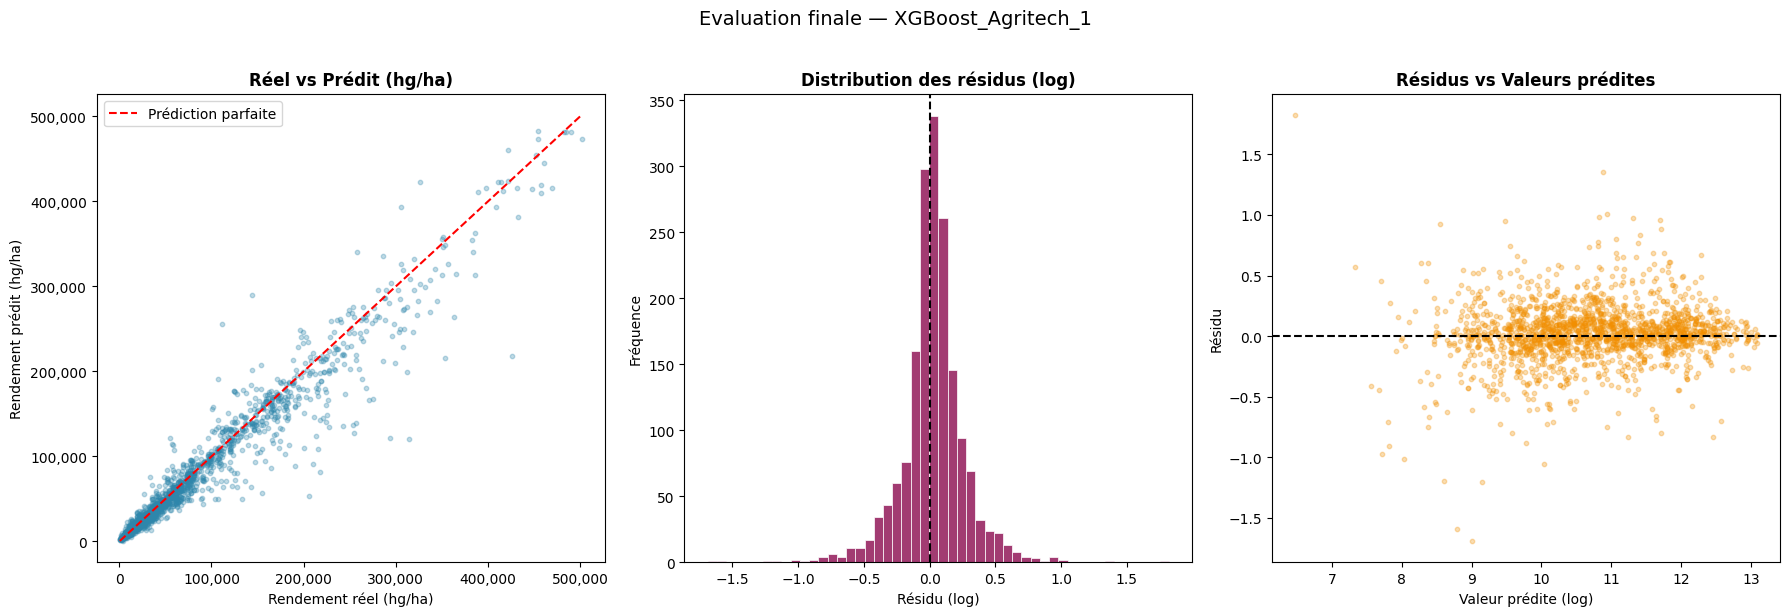

Visualisation sauvegardée : ../outputs/evaluation_finale.png


In [30]:
# visualisations d'évaluation

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(y_test_reel, y_pred_reel, alpha=0.3, s=10, color="#2E86AB")
lims = [
    min(y_test_reel.min(), y_pred_reel.min()),
    max(y_test_reel.max(), y_pred_reel.max())
]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Prédiction parfaite")
axes[0].set_title("Réel vs Prédit (hg/ha)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rendement réel (hg/ha)")
axes[0].set_ylabel("Rendement prédit (hg/ha)")
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

residus = y_test.values - y_pred_log
axes[1].hist(residus, bins=50, color="#A23B72", edgecolor="white", linewidth=0.5)
axes[1].axvline(x=0, color="black", linewidth=1.5, linestyle="--")
axes[1].set_title("Distribution des résidus (log)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Résidu (log)")
axes[1].set_ylabel("Fréquence")

axes[2].scatter(y_pred_log, residus, alpha=0.3, s=10, color="#F18F01")
axes[2].axhline(y=0, color="black", linewidth=1.5, linestyle="--")
axes[2].set_title("Résidus vs Valeurs prédites", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Valeur prédite (log)")
axes[2].set_ylabel("Résidu")

plt.suptitle("Evaluation finale — XGBoost_Agritech_1", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/evaluation_finale.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisation sauvegardée : ../outputs/evaluation_finale.png")

=== Importance des features — XGBoost_Agritech_1 ===
                      Feature  Importance
                         Item    0.727409
average_rain_fall_mm_per_year    0.097321
                     avg_temp    0.058659
                         Area    0.055738
            pesticides_tonnes    0.052179
                         Year    0.008695


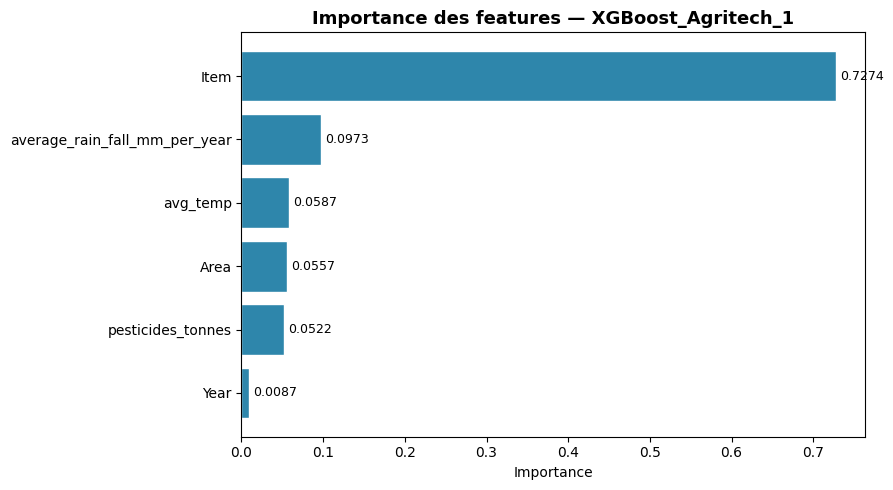

Visualisation sauvegardée : ../outputs/feature_importance.png


In [31]:
# Features importance

modele_final = XGBoost_Agritech_1.named_steps["modele"]

importances  = modele_final.feature_importances_
feature_names = FEATURES_NUM + FEATURES_CAT

df_importance = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("=== Importance des features — XGBoost_Agritech_1 ===")
print(df_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    df_importance["Feature"][::-1],
    df_importance["Importance"][::-1],
    color="#2E86AB", edgecolor="white"
)
ax.bar_label(
    bars,
    labels=[f"{v:.4f}" for v in df_importance["Importance"][::-1]],
    padding=3, fontsize=9
)
ax.set_title("Importance des features — XGBoost_Agritech_1", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisation sauvegardée : ../outputs/feature_importance.png")

=== Permutation Importance — XGBoost_Agritech_1 ===
                      Feature  Importance_mean  Importance_std
                         Item         1.496506        0.039984
                     avg_temp         0.151197        0.005563
average_rain_fall_mm_per_year         0.147694        0.004339
            pesticides_tonnes         0.117280        0.004214
                         Area         0.082682        0.002598
                         Year         0.000000        0.000000


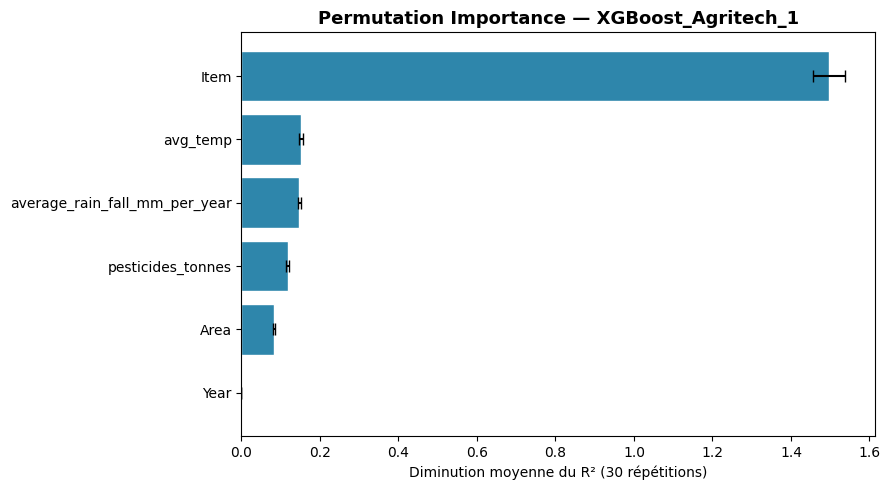

Visualisation sauvegardée : ../outputs/permutation_importance.png


In [34]:
# Permutation importance

modele_xgb    = XGBoost_Agritech_1.named_steps["modele"]
preprocesseur = XGBoost_Agritech_1.named_steps["preprocesseur"]

X_test_transforme = preprocesseur.transform(X_test)

result = permutation_importance(
    modele_xgb,
    X_test_transforme,
    y_test,
    n_repeats    = 30,
    random_state = RANDOM_STATE,
    n_jobs       = -1,
    scoring      = "r2"
)

feature_names = FEATURES_NUM + FEATURES_CAT

df_perm = pd.DataFrame({
    "Feature"         : feature_names,
    "Importance_mean" : result.importances_mean,
    "Importance_std"  : result.importances_std,
}).sort_values("Importance_mean", ascending=False)

print("=== Permutation Importance — XGBoost_Agritech_1 ===")
print(df_perm.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    df_perm["Feature"][::-1],
    df_perm["Importance_mean"][::-1],
    xerr        = df_perm["Importance_std"][::-1],
    color       = "#2E86AB",
    edgecolor   = "white",
    capsize     = 4,
)
ax.set_title("Permutation Importance — XGBoost_Agritech_1", fontsize=13, fontweight="bold")
ax.set_xlabel("Diminution moyenne du R² (30 répétitions)")
plt.tight_layout()
plt.savefig("../outputs/permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisation sauvegardée : ../outputs/permutation_importance.png")

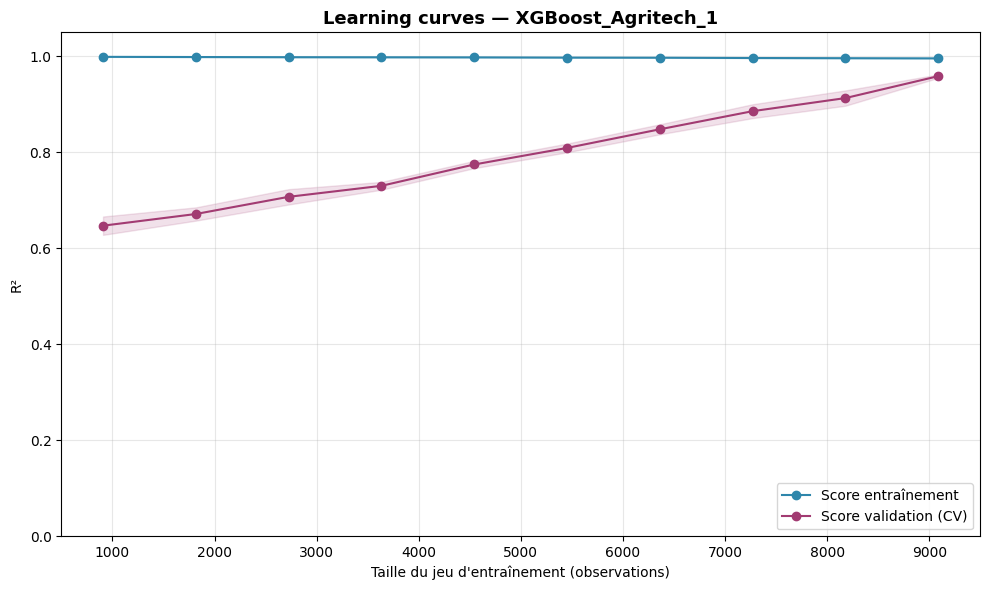

Score entraînement final   : 0.9958 (+/- 0.0002)
Score validation final     : 0.9586 (+/- 0.0035)
Ecart train/validation     : 0.0371


In [39]:
# Vérification d'un éventuel surapprentissage (overfitting) ou sous-apprentissage (underfitting)

train_sizes, train_scores, val_scores = learning_curve(
    XGBoost_Agritech_1,
    X_train, y_train,
    train_sizes = np.linspace(0.1, 1.0, 10),
    cv          = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring     = "r2",
    n_jobs      = -1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, "o-", color="#2E86AB", label="Score entraînement")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#2E86AB")

ax.plot(train_sizes, val_mean, "o-", color="#A23B72", label="Score validation (CV)")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#A23B72")

ax.set_title("Learning curves — XGBoost_Agritech_1", fontsize=13, fontweight="bold")
ax.set_xlabel("Taille du jeu d'entraînement (observations)")
ax.set_ylabel("R²")
ax.legend(loc="lower right")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Score entraînement final   : {train_mean[-1]:.4f} (+/- {train_std[-1]:.4f})")
print(f"Score validation final     : {val_mean[-1]:.4f} (+/- {val_std[-1]:.4f})")
print(f"Ecart train/validation     : {train_mean[-1] - val_mean[-1]:.4f}")

=== Performance par culture — jeu de test ===
             Culture  N_obs  RMSE (hg/ha)     R²
            Soybeans    170        3025.0 0.8664
               Wheat    240        5864.0 0.9213
         Rice, paddy    198        7473.0 0.8742
               Maize    273       11795.0 0.8770
             Sorghum    194       12826.0 0.6632
                Yams     60       25249.0 0.7362
             Cassava    123       31814.0 0.8143
            Potatoes    282       32660.0 0.9035
Plantains and others     63       36045.0 0.6819
      Sweet potatoes    153       40874.0 0.7610


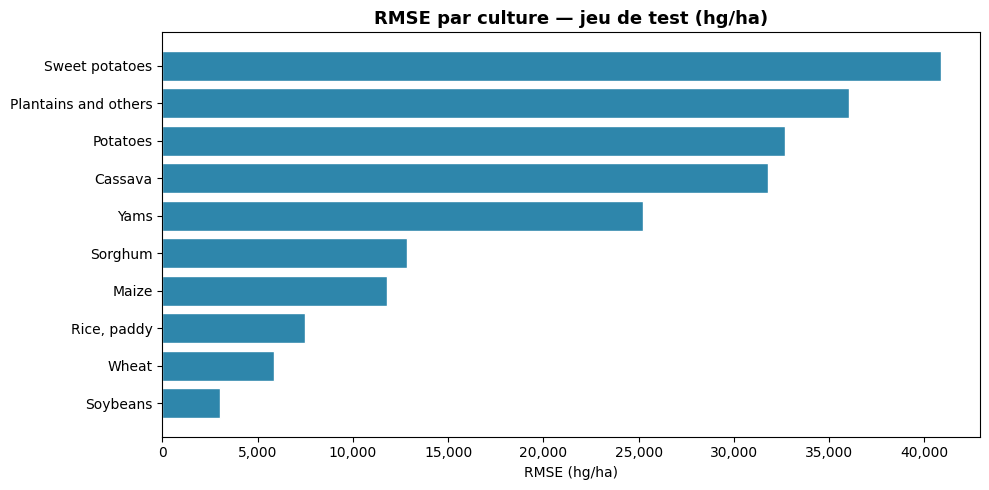

Visualisation sauvegardée : ../outputs/rmse_par_culture.png


In [36]:
# Performance par culture

df_test_analyse = X_test.copy()
df_test_analyse["y_reel"]   = y_test_reel.values
df_test_analyse["y_predit"] = y_pred_reel

resultats_par_culture = []
for culture in sorted(df_test_analyse["Item"].unique()):
    mask   = df_test_analyse["Item"] == culture
    y_r    = df_test_analyse.loc[mask, "y_reel"]
    y_p    = df_test_analyse.loc[mask, "y_predit"]
    rmse_c = root_mean_squared_error(y_r, y_p)
    r2_c   = r2_score(y_r, y_p)
    resultats_par_culture.append({
        "Culture"     : culture,
        "N_obs"       : int(mask.sum()),
        "RMSE (hg/ha)": round(rmse_c, 0),
        "R²"          : round(r2_c, 4)
    })

df_par_culture = pd.DataFrame(resultats_par_culture).sort_values("RMSE (hg/ha)")

print("=== Performance par culture — jeu de test ===")
print(df_par_culture.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    df_par_culture["Culture"],
    df_par_culture["RMSE (hg/ha)"],
    color="#2E86AB", edgecolor="white"
)
ax.set_title("RMSE par culture — jeu de test (hg/ha)", fontsize=13, fontweight="bold")
ax.set_xlabel("RMSE (hg/ha)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../outputs/rmse_par_culture.png", dpi=150, bbox_inches="tight")
plt.show()
print("Visualisation sauvegardée : ../outputs/rmse_par_culture.png")

In [37]:
# Sauvegarde du pipeline final

MODEL_PATH = os.path.join("..", "outputs", "model_pipeline.pkl")
joblib.dump(XGBoost_Agritech_1, MODEL_PATH)
print(f"Pipeline sauvegardé : {MODEL_PATH}")

metadata = {
    "modele_champion"     : "XGBoost_Agritech_1",
    "features_num"        : FEATURES_NUM,
    "features_cat"        : FEATURES_CAT,
    "features_all"        : FEATURES_ALL,
    "target"              : TARGET,
    "target_transform"    : "log1p",
    "cultures_disponibles": sorted(df["Item"].unique().tolist()),
    "pays_disponibles"    : sorted(df["Area"].unique().tolist()),
    "annees_train"        : f"1990-{SEUIL_TEMPOREL}",
    "metriques_test": {
        "rmse_log"  : round(rmse_log, 4),
        "r2_log"    : round(r2_log, 4),
        "rmse_hgha" : round(rmse_reel, 0),
        "r2_hgha"   : round(r2_reel, 4),
    }
}

META_PATH = os.path.join("..", "outputs", "model_metadata.json")
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"Métadonnées sauvegardées : {META_PATH}")
print()
print(f"  Cultures : {len(metadata['cultures_disponibles'])}")
print(f"  Pays     : {len(metadata['pays_disponibles'])}")
print(f"  Pipeline : {MODEL_PATH}")
print(f"  Metadata : {META_PATH}")

Pipeline sauvegardé : ../outputs/model_pipeline.pkl
Métadonnées sauvegardées : ../outputs/model_metadata.json

  Cultures : 10
  Pays     : 100
  Pipeline : ../outputs/model_pipeline.pkl
  Metadata : ../outputs/model_metadata.json


### <u>Evaluation finale sur le jeu de test</u>

#### Métriques finales — XGBoost_Agritech_1

| Métrique | Echelle log | Echelle hg/ha |
|---|---|---|
| RMSE | 0.2479 | 22 535 hg/ha |
| R² | 0.9524 | 0.9348 |
| MAE | 0.1656 | 11 278 hg/ha |

- Le modèle généralise bien sur les années 2011-2013 (données jamais vues à l'entraînement).
- Un R² de 0.9348 en échelle originale signifie que le modèle explique 93.48% de la variance du rendement réel.
- Résultat solide pour des données agricoles multi-pays sur une décennie d'extrapolation temporelle.

Le RMSE de 22 535 hg/ha (soit environ 2.25 t/ha) est à mettre en regard de la plage de
rendements du dataset : de quelques milliers à plus de 500 000 hg/ha selon la culture
et le pays. L'erreur est concentrée sur les cultures à fort rendement (Sweet potatoes,
Plantains, Potatoes) qui présentent une forte variabilité intrinsèque.

---

### <u>Interprétabilité et recommandations métier</u>

#### Feature importance native XGBoost — XGBoost_Agritech_1

| Feature | Importance |
|---|---|
| Item (culture) | 0.7274 |
| average_rain_fall_mm_per_year | 0.0973 |
| avg_temp | 0.0587 |
| Area (pays) | 0.0557 |
| pesticides_tonnes | 0.0522 |
| Year | 0.0087 |

#### Permutation importance (diminution moyenne du R², 30 répétitions)

| Feature | Importance moyenne | Ecart-type |
|---|---|---|
| Item (culture) | 1.4965 | 0.0400 |
| avg_temp | 0.1512 | 0.0056 |
| average_rain_fall_mm_per_year | 0.1477 | 0.0043 |
| pesticides_tonnes | 0.1173 | 0.0042 |
| Area (pays) | 0.0827 | 0.0026 |
| Year | 0.0000 | 0.0000 |

Les deux méthodes convergent : la variable `Item` (<mark>type de culture</mark>) domine très
largement avec **72.74%** de l'importance native et une chute de R² de **1.50 points**
en permutation. Le choix de la culture est de loin le facteur le plus déterminant du
rendement — résultat cohérent avec les données FAO qui montrent des écarts structurels
très importants entre cultures (Potatoes ~180 000 hg/ha vs Soybeans ~20 000 hg/ha).

La permutation importance révèle une nuance par rapport à l'importance native :
<mark>avg_temp</mark> passe devant `average_rain_fall_mm_per_year` (0.151 vs 0.148).
L'importance native surestimait légèrement la pluviométrie à cause du biais de cardinalité
inhérent au gain XGBoost. Les deux méthodes confirment que <u>température</u> et
<u>pluviométrie</u> contribuent de façon quasi équivalente au rendement (~10% chacune).

`Year` présente une importance nulle en permutation — le modèle ne s'appuie pas sur
l'année comme signal prédictif, ce qui valide notre split temporel : la généralisation
sur 2011-2013 repose sur les conditions agronomiques et climatiques, non sur une
extrapolation de tendance.

#### Learning curves — XGBoost_Agritech_1

| Métrique | Valeur |
|---|---|
| Score entraînement final | 0.9958 (+/- 0.0002) |
| Score validation final (CV) | 0.9586 (+/- 0.0035) |
| Ecart train / validation | 0.0371 |

Le modèle présente un overfitting modéré : le score d'entraînement est quasi parfait
(0.9958) tandis que la validation plafonne à 0.9586. L'écart de 0.0371 est stable et
contenu — il ne s'agit pas d'un overfitting sévère.

La courbe de validation est encore croissante à 9 000 observations, ce qui indique que
le modèle bénéficierait de données supplémentaires. Dans le contexte des données FAO
(13 116 observations, 10 cultures, 100 pays, 23 années), cette limite est structurelle
et non corrigeable par l'optimisation des hyperparamètres seule.

Ce comportement est cohérent avec les métriques sur le jeu de test (R²=0.9348) :
le modèle généralise correctement malgré l'overfitting observé en CV, ce qui confirme
que les paramètres de régularisation (`reg_lambda=5.0`, `min_child_weight=3`) jouent
bien leur rôle de contrainte.

---
#### Performance par culture — jeu de test

| Culture | N obs | RMSE (hg/ha) | R² |
|---|---|---|---|
| Soybeans | 170 | 3 025 | 0.8664 |
| Wheat | 240 | 5 864 | 0.9213 |
| Rice, paddy | 198 | 7 473 | 0.8742 |
| Maize | 273 | 11 795 | 0.8770 |
| Sorghum | 194 | 12 826 | 0.6632 |
| Yams | 60 | 25 249 | 0.7362 |
| Cassava | 123 | 31 814 | 0.8143 |
| Potatoes | 282 | 32 660 | 0.9035 |
| Plantains and others | 63 | 36 045 | 0.6819 |
| Sweet potatoes | 153 | 40 874 | 0.7610 |

Les cultures à faible rendement absolu (Soybeans, Wheat, Rice) présentent les RMSE les
plus bas. Le modèle les prédit avec précision. Les cultures à haut rendement (Sweet
potatoes, Plantains, Potatoes) affichent des RMSE élevés en valeur absolue mais des R²
corrects (0.76-0.90), ce qui indique que l'erreur est proportionnelle à l'échelle de
rendement et non un signal de sous-performance structurelle.

Sorghum et Plantains présentent les R² les plus faibles (0.66-0.68) — cultures sous-
représentées dans le dataset (60 et 63 observations en test) avec une forte variabilité
géographique. Ce sont les cultures pour lesquelles les recommandations de l'application
devront être interprétées avec le plus de prudence.